# Specialty x year x location pivot, and colocados cross-check

Full pivot of seat counts (specialty, year, location), plus the one hard invariant from CLAUDE.md: for a given specialty/year, `colocados` (placements) must never exceed `vagas` (seats) -- if it does, that's an extraction bug, not a real oversubscription.

In [1]:
import csv
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

def load(name):
    with open(ROOT / "data" / "processed" / f"{name}.csv", encoding="utf-8") as f:
        return list(csv.DictReader(f))

vagas = load("vagas")
colocados = load("colocados")
print(f"vagas: {len(vagas)} rows, colocados: {len(colocados)} rows")


vagas: 4177 rows, colocados: 5489 rows


## Specialty totals by year (seats)

Specialty and location both uppercased for display.

Plotted after the table below (top 15 specialties by total seats across all years).

In [2]:
specialty_year_seats = defaultdict(lambda: defaultdict(int))
specialties = set()
for r in vagas:
    spec = r['specialty'].upper()
    specialty_year_seats[spec][r['year']] += int(r['seats'])
    specialties.add(spec)

years_sorted = sorted({r['year'] for r in vagas})
header = 'SPECIALTY'.ljust(55) + ''.join(y.rjust(8) for y in years_sorted)
print(header)
for spec in sorted(specialties):
    row = spec.ljust(55) + ''.join(str(specialty_year_seats[spec].get(y, 0)).rjust(8) for y in years_sorted)
    print(row)


SPECIALTY                                                  2021    2022    2023    2024    2025
ANATOMIA PATOLÓGICA                                          18      16      19      17      14
ANESTESIOLOGIA                                               80      85      98      92      96
ANGIOLOGIA E CIRURGIA VASCULAR                                9       7       9       9      11
CARDIOLOGIA                                                  39      36      46      37      41
CARDIOLOGIA PEDIÁTRICA                                        2       3       4       5       5
CIRURGIA CARDÍACA                                             2       3       5       6       2
CIRURGIA GERAL                                               74      72      85      84      78
CIRURGIA MAXILOFACIAL                                         6       6       6       7       8
CIRURGIA PEDIÁTRICA                                           7       5       7      17      22
CIRURGIA PLÁSTICA, RECONSTRUTIVA E ESTÉT

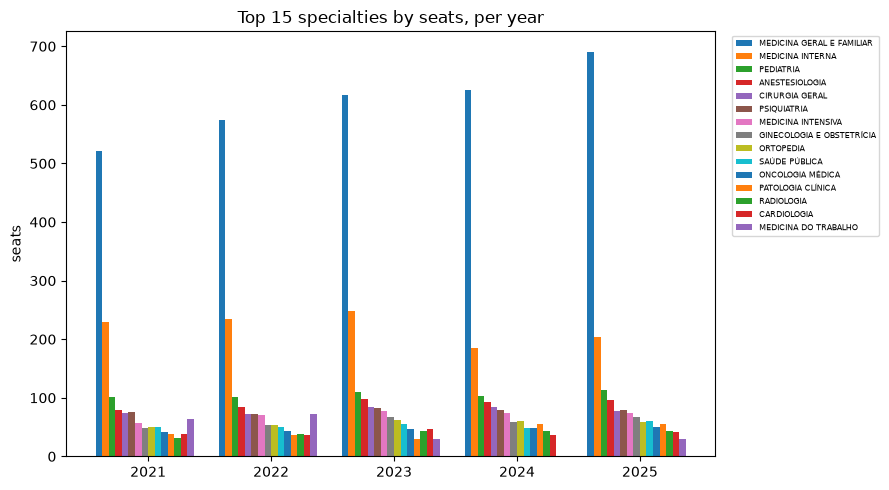

In [3]:
top15 = sorted(specialties, key=lambda s: -sum(specialty_year_seats[s].values()))[:15]
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(years_sorted))
width = 0.8 / len(top15)
for i, spec in enumerate(top15):
    vals = [specialty_year_seats[spec].get(y, 0) for y in years_sorted]
    ax.bar([xi + i * width for xi in x], vals, width=width, label=spec[:25])
ax.set_xticks([xi + width * len(top15) / 2 for xi in x])
ax.set_xticklabels(years_sorted)
ax.set_ylabel('seats')
ax.set_title('Top 15 specialties by seats, per year')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()


## Specialty x year x location pivot (seats)

One row per (specialty, location); columns are years. Only the top few by total seats are printed here -- the full pivot is large.

In [4]:
pivot = defaultdict(lambda: defaultdict(int))
for r in vagas:
    loc = (r['region_key'] or 'UNMAPPED').upper()
    spec = r['specialty'].upper()
    pivot[(spec, loc)][r['year']] += int(r['seats'])

ranked = sorted(pivot.items(), key=lambda kv: -sum(kv[1].values()))
header = 'SPECIALTY'.ljust(45) + 'LOCATION'.ljust(16) + ''.join(y.rjust(7) for y in years_sorted)
print(header)
for (spec, loc), by_year in ranked[:40]:
    row = spec.ljust(45) + loc.ljust(16) + ''.join(str(by_year.get(y, 0)).rjust(7) for y in years_sorted)
    print(row)
print(f"\n... {len(ranked) - 40} more (specialty, location) pairs not shown")


SPECIALTY                                    LOCATION           2021   2022   2023   2024   2025
MEDICINA GERAL E FAMILIAR                    NORTE               172    182      0    217    233
MEDICINA GERAL E FAMILIAR                    LISBOA-VALE-TEJO    176    200      0    190    221
MEDICINA GERAL E FAMILIAR                    UNMAPPED              0      0    617      0      0
MEDICINA GERAL E FAMILIAR                    CENTRO              114    114      0    124    141
MEDICINA INTERNA                             LISBOA-VALE-TEJO     82     81     92     62     71
MEDICINA INTERNA                             NORTE                75     79     81     64     67
PEDIATRIA                                    NORTE                38     37     41     41     43
PEDIATRIA                                    LISBOA-VALE-TEJO     35     39     40     36     42
ANESTESIOLOGIA                               NORTE                32     34     41     41     42
MEDICINA INTERNA              

## Colocados vs vagas: placements should never exceed seats

Per (year, specialty): sum of `vagas.seats` vs count of `colocados` rows. A specialty/year with more placements than seats is a red flag on the extraction, not real oversubscription (see CLAUDE.md's seats-vs-colocados note).

In [5]:
seats_by_year_spec = defaultdict(int)
for r in vagas:
    seats_by_year_spec[(r['year'], r['specialty'].upper())] += int(r['seats'])

placed_by_year_spec = defaultdict(int)
for r in colocados:
    placed_by_year_spec[(r['year'], r['specialty'].upper())] += 1

violations = []
for key, placed in placed_by_year_spec.items():
    seats = seats_by_year_spec.get(key, 0)
    if placed > seats:
        violations.append((key, seats, placed))

print(f"{len(violations)} (year, specialty) pairs have MORE placements than seats:\n")
for (year, spec), seats, placed in sorted(violations, key=lambda v: -(v[2]-v[1])):
    print(f"  {year} {spec:50s} seats={seats:5d} placed={placed:5d} (+{placed-seats})")


26 (year, specialty) pairs have MORE placements than seats:

  2025 UROLOGIA                                           seats=   18 placed=   59 (+41)
  2024 UROLOGIA                                           seats=   18 placed=   57 (+39)
  2024 MEDICINA DO TRABALHO                               seats=    0 placed=   27 (+27)
  2024 PSIQUIATRIA                                        seats=   80 placed=  104 (+24)
  2024 RADIOLOGIA                                         seats=   43 placed=   63 (+20)
  2025 RADIOLOGIA                                         seats=   44 placed=   64 (+20)
  2024 PEDIATRIA                                          seats=  103 placed=  109 (+6)
  2024 CIRURGIA GERAL                                     seats=   84 placed=   89 (+5)
  2024 MEDICINA INTENSIVA                                 seats=   74 placed=   77 (+3)
  2024 ANESTESIOLOGIA                                     seats=   92 placed=   95 (+3)
  2024 OTORRINOLARINGOLOGIA                          

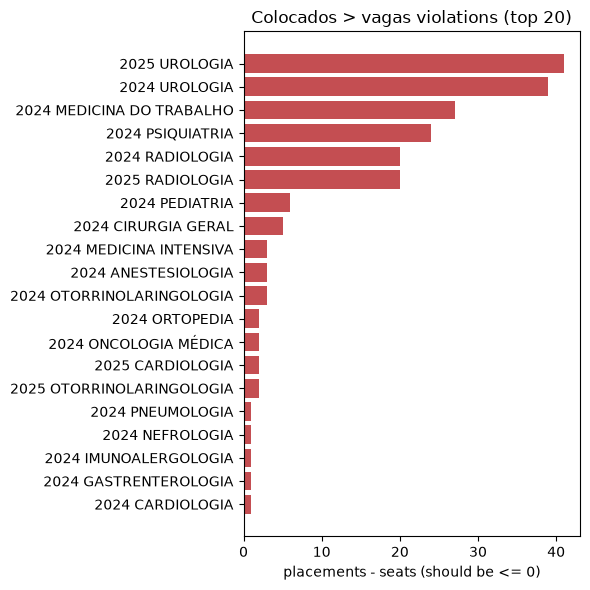

In [6]:
if violations:
    labels = [f'{y} {s[:22]}' for (y, s), _, _ in sorted(violations, key=lambda v: -(v[2]-v[1]))[:20]]
    overs = [p - s for (_, _), s, p in sorted(violations, key=lambda v: -(v[2]-v[1]))[:20]]
    fig, ax = plt.subplots(figsize=(6, max(3, len(labels) * 0.3)))
    ax.barh(labels[::-1], overs[::-1], color='#C44E52')
    ax.set_xlabel('placements - seats (should be <= 0)')
    ax.set_title('Colocados > vagas violations (top 20)')
    plt.tight_layout()
    plt.show()


Down from 16 large violations to a couple dozen small ones (single digits to ~20 seats over, not hundreds) after fixing the seat double-count -- the residual gap is plausibly real placement process detail (reallocated/carry-over seats not present in that year's initial `vagas` offer) rather than an extraction bug, but each remaining pair is still worth a manual PDF check before trusting it at the seat level.